In [18]:
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import scipy.stats as st
from matplotlib.transforms import ScaledTranslation

from chargers import *
from metrics import *
from graphs import *

## Abortion Experiment

In [19]:
column_to_predict_abortion = "religion_14"
n_options_abortion = 3

d_abortion = {
  "abortion should be prohibited in all cases": 1,
  "always prohibited": 1,
  "always be prohibited": 1,
  "abortion should always be prohibited": 1,
  "abortion should always be prohibited.": 1,
  "abortion should be allowed in cases of special circumstances": 2,
  "abortion should be prohibited except in special cases": 2,
  "abortion should only be allowed in special cases.": 2,
  "abortion should only be allowed in special cases": 2,
  "abortion should be allowed only in special cases": 2,
  "abortion should be allowed in special cases": 2,
  "abortion should be only allowed in special cases": 2,
  "in special cases": 2,
  "abortion should be permitted in any case": 3,
  "abortion should be allowed in any case": 3,
  "abortion should be an option for women in any case.": 3,
  "abortion should be an option for women in any case": 3,
  "1": 1,
  "2": 2,
  "3": 3,
}

# Paths
abortion_route = "../results_dataframes/USA_abortion/"
experiments_route = "../../Data/Experiments/"
anes_file = abortion_route + "anes_2020_660.csv"

# Load religion_14 values from RF CSV (for models whose input file lacks it)
rf_abortion_full = pd.read_csv(experiments_route + "randomforest_3_eeuu.csv")
# RF abortion has 0-indexed religion_14 (0,1,2) and pred -> shift both to 1-indexed
rf_abortion_full["religion_14"] = rf_abortion_full["religion_14"] + 1
rf_abortion_full["pred"] = rf_abortion_full["pred"] + 1
religion_14_values = rf_abortion_full["religion_14"].values

In [20]:
# --- Random Forest (abortion) ---
df_rf_abortion = rf_abortion_full.copy()

# --- Llama (abortion) --- pre-processed CSV already has religion_14 and pred
llama_abortion = pd.read_csv(experiments_route + "llama_aborto_eeuu.csv")

# --- GPT-3.5 (abortion) --- CSV already has 660 rows with religion_14 and raw pred text
gpt3_abortion_df = pd.read_csv(abortion_route + "abortion_usa_chatgpt3_cot.csv")
gpt3_abortion = data_charger(anes_file, gpt3_abortion_df, d_abortion, prompt_type='cot')
gpt3_abortion["religion_14"] = religion_14_values

# --- GPT-4 (abortion) ---
gpt4_abortion_df = pd.read_csv(abortion_route + "abortion_usa_chatgpt4_cot.csv")
gpt4_abortion = data_charger(anes_file, gpt4_abortion_df, d_abortion, prompt_type='cot')
gpt4_abortion["religion_14"] = religion_14_values

# --- Mistral (abortion) --- 660 entries JSONL
mistral_abortion = data_charger(anes_file, abortion_route + "abortion_usa_mistral_cot.jsonl",
                                d_abortion, prompt_type='cot')
mistral_abortion["religion_14"] = religion_14_values

# --- T0 (abortion) --- 660 entries JSONL
t0_abortion = data_charger(anes_file, abortion_route + "abortion_usa_t0_cot.jsonl",
                           d_abortion, prompt_type='cot', is_t0=True)
t0_abortion["religion_14"] = religion_14_values

print("Abortion data loaded:")
print(f"  RF: {len(df_rf_abortion)} rows")
print(f"  Llama: {len(llama_abortion)} rows")
print(f"  GPT-3.5: {len(gpt3_abortion)} rows")
print(f"  GPT-4: {len(gpt4_abortion)} rows")
print(f"  Mistral: {len(mistral_abortion)} rows")
print(f"  T0: {len(t0_abortion)} rows")

Abortion data loaded:
  RF: 660 rows
  Llama: 660 rows
  GPT-3.5: 660 rows
  GPT-4: 660 rows
  Mistral: 660 rows
  T0: 660 rows


In [21]:
results_rf_abortion

,Group,JSD,Accuracy,Harmonic Mean,JSS,Kappa,JSD_CI_lower,JSD_CI_upper,Accuracy_CI_lower,Accuracy_CI_upper,Harmonic Mean_CI_lower,Harmonic Mean_CI_upper,JSS_CI_lower,JSS_CI_upper,Kappa_CI_lower,Kappa_CI_upper
0,Woman,0.266111,0.690476,0.711521,0.733889,0.393649,0.231370,0.303392,0.642857,0.735119,0.672447,0.747203,0.696608,0.768630,0.315661,0.472478
1,Man,0.237045,0.689441,0.724338,0.762955,0.433258,0.202001,0.271782,0.639752,0.736102,0.684638,0.761169,0.728218,0.797999,0.349023,0.515169
2,Young adult,0.238336,0.727273,0.744071,0.761664,0.418787,0.139390,0.351867,0.575758,0.878788,0.606294,0.869423,0.648133,0.860610,0.159593,0.700000
3,Adult,0.272784,0.661017,0.692538,0.727216,0.356549,0.236178,0.309749,0.610099,0.711864,0.651251,0.733211,0.690251,0.763822,0.276340,0.435342
4,Senior adult,0.232383,0.721612,0.743904,0.767617,0.489669,0.190321,0.275120,0.670330,0.772894,0.702282,0.787006,0.724880,0.809679,0.403879,0.577199
5,City/Suburb,0.293830,0.667910,0.686508,0.706170,0.428188,0.255843,0.336717,0.615672,0.720149,0.645013,0.727953,0.663283,0.744157,0.348396,0.510279
6,Small town/Rural,0.224241,0.704082,0.738184,0.775759,0.373698,0.190029,0.259537,0.660714,0.750000,0.703272,0.774690,0.740463,0.809971,0.293488,0.456195
7,White,0.250029,0.697211,0.722629,0.749971,0.451177,0.218253,0.281413,0.655378,0.739044,0.688954,0.757343,0.718587,0.781747,0.380673,0.517454
8,Non-White,0.311497,0.664516,0.676297,0.688503,0.232015,0.255082,0.365231,0.593548,0.741935,0.617294,0.737387,0.634769,0.744918,0.117967,0.356738
9,Low education,0.290350,0.607477,0.654600,0.709650,0.320429,0.221686,0.354666,0.504673,0.700935,0.574371,0.726846,0.645334,0.778314,0.170002,0.464548


/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:697: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:697: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:697: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:697: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/metri

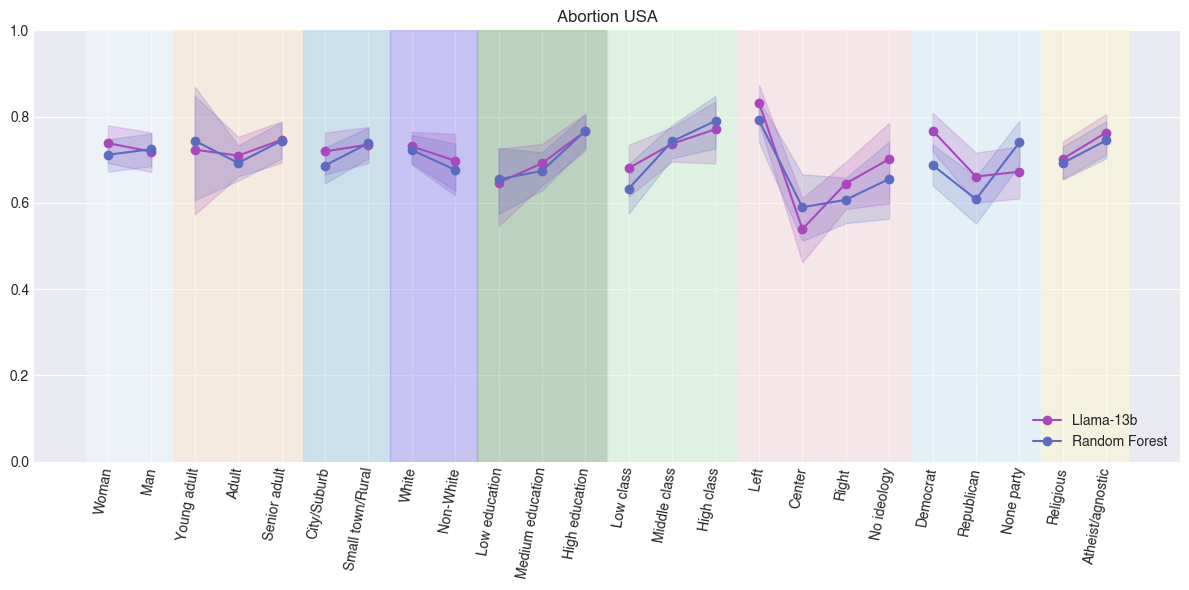

In [22]:
# Compute metrics for abortion experiment
results_rf_abortion = metrics_dataset_gen_usa(df_rf_abortion, "religion_14", n_options=3, n_bootstrap=1000, random_seed=42)
results_llama_abortion = metrics_dataset_gen_usa(llama_abortion, "religion_14", n_options=3, n_bootstrap=1000, random_seed=42)
results_gpt3_abortion = metrics_dataset_gen_usa(gpt3_abortion, "religion_14", n_options=3, n_bootstrap=1000, random_seed=42)
results_gpt4_abortion = metrics_dataset_gen_usa(gpt4_abortion, "religion_14", n_options=3, n_bootstrap=1000, random_seed=42)
results_mistral_abortion = metrics_dataset_gen_usa(mistral_abortion, "religion_14", n_options=3, n_bootstrap=1000, random_seed=42)
results_t0_abortion = metrics_dataset_gen_usa(t0_abortion, "religion_14", n_options=3, n_bootstrap=1000, random_seed=42)

# Per-experiment plot: Llama vs RF
modelos_colores = {
    "Random Forest": "#5c6bc0",
    "ChatGPT-4": "#66bb6a",
    "ChatGPT-3.5": "#ff7043",
    "Llama-13b": "#ab47bc",
    "Mistral-Intruct-v0.2": "#ffa726",
    "T-zero": "#f48fb1",
}

sociodemographic_line_plot_usa(
    [results_llama_abortion, results_rf_abortion],
    modelos_colores,
    ["Llama-13b", "Random Forest"],
    "Abortion USA"
)

## Presidential Experiment

In [23]:
column_to_predict_presidential = "elec_pres_144_a"
n_options_presidential = 4

d_presidential = {
    "joe biden": 1,
    "biden": 1,
    "donald trump": 2,
    "trump": 2,
    "jo jorgensen": 3,
    "jorgensen": 3,
    "howie hawkins": 4,
    "hawkins": 4,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
}

presidential_route = "../results_dataframes/USA_presidential/"

In [24]:
# --- Random Forest (presidential) --- 0-indexed -> +1
df_rf_presidential = pd.read_csv(experiments_route + "randomforest_1_eeuu.csv")
df_rf_presidential["elec_pres_144_a"] = df_rf_presidential["elec_pres_144_a"] + 1
df_rf_presidential["pred"] = df_rf_presidential["pred"] + 1

# --- Llama (presidential) --- pre-processed CSV
llama_presidential = pd.read_csv(experiments_route + "llama_presidencial_eeuu.csv")

# --- GPT-3.5 (presidential) ---
gpt3_presidential_df = pd.read_csv(presidential_route + "presidential_usa_chatgpt3_cot.csv")
gpt3_presidential = data_charger(anes_file, gpt3_presidential_df, d_presidential, prompt_type='cot')

# --- GPT-4 (presidential) ---
gpt4_presidential_df = pd.read_csv(presidential_route + "presidential_usa_chatgpt4_cot.csv")
gpt4_presidential = data_charger(anes_file, gpt4_presidential_df, d_presidential, prompt_type='cot')

# --- Mistral (presidential) --- 660 entries JSONL
mistral_presidential = data_charger(anes_file, presidential_route + "presidential_usa_mistral_cot.jsonl",
                                    d_presidential, prompt_type='cot')

# --- T0 (presidential) --- 660 entries JSONL
t0_presidential = data_charger(anes_file, presidential_route + "presidential_usa_t0_cot.jsonl",
                               d_presidential, prompt_type='cot', is_t0=True)

print("Presidential data loaded:")
print(f"  RF: {len(df_rf_presidential)} rows")
print(f"  Llama: {len(llama_presidential)} rows")
print(f"  GPT-3.5: {len(gpt3_presidential)} rows")
print(f"  GPT-4: {len(gpt4_presidential)} rows")
print(f"  Mistral: {len(mistral_presidential)} rows")
print(f"  T0: {len(t0_presidential)} rows")

Presidential data loaded:
  RF: 660 rows
  Llama: 660 rows
  GPT-3.5: 660 rows
  GPT-4: 660 rows
  Mistral: 660 rows
  T0: 660 rows


/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:697: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:697: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:697: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:697: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/aabeliuk/miniforge3/envs/torch_env/lib/python3.10/site-packages/sklearn/metri

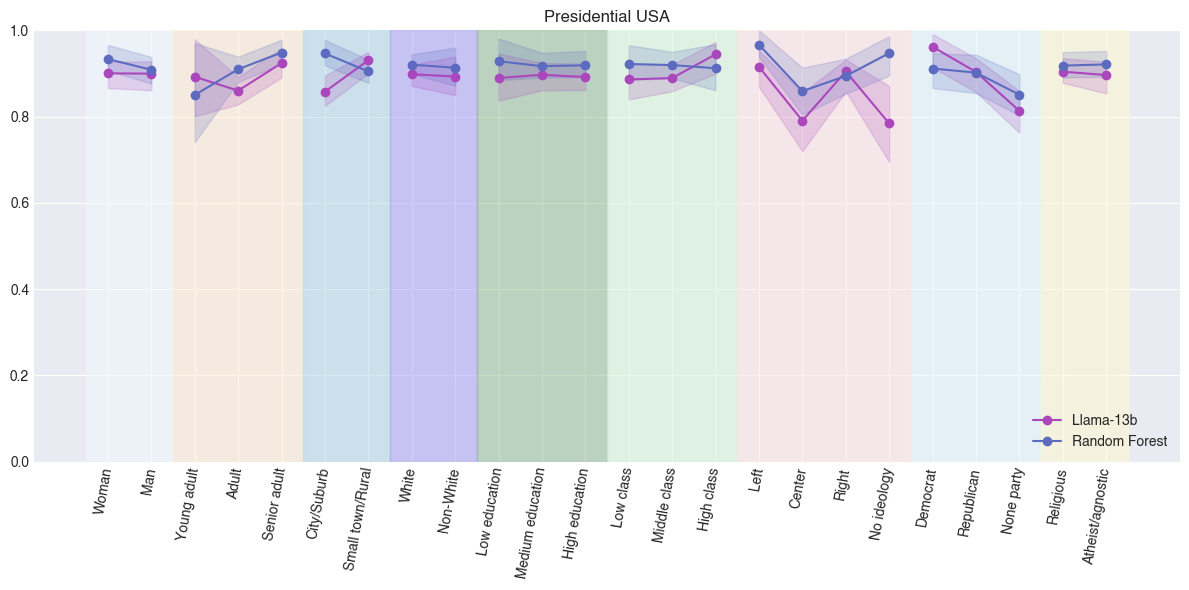

In [25]:
# Compute metrics for presidential experiment
results_rf_presidential = metrics_dataset_gen_usa(df_rf_presidential, "elec_pres_144_a", n_options=4, n_bootstrap=1000, random_seed=42)
results_llama_presidential = metrics_dataset_gen_usa(llama_presidential, "elec_pres_144_a", n_options=4, n_bootstrap=1000, random_seed=42)
results_gpt3_presidential = metrics_dataset_gen_usa(gpt3_presidential, "elec_pres_144_a", n_options=4, n_bootstrap=1000, random_seed=42)
results_gpt4_presidential = metrics_dataset_gen_usa(gpt4_presidential, "elec_pres_144_a", n_options=4, n_bootstrap=1000, random_seed=42)
results_mistral_presidential = metrics_dataset_gen_usa(mistral_presidential, "elec_pres_144_a", n_options=4, n_bootstrap=1000, random_seed=42)
results_t0_presidential = metrics_dataset_gen_usa(t0_presidential, "elec_pres_144_a", n_options=4, n_bootstrap=1000, random_seed=42)

# Per-experiment plot: Llama vs RF
sociodemographic_line_plot_usa(
    [results_llama_presidential, results_rf_presidential],
    modelos_colores,
    ["Llama-13b", "Random Forest"],
    "Presidential USA"
)

# Aggregated plots

In [26]:
z = st.norm.ppf(0.975)  # ~1.96 for 95% CI
metric_cols = ["JSD", "Accuracy", "Harmonic Mean", "JSS", "Kappa"]

def aggregate_model_metrics(all_metrics_list):
    """Average metrics across experiments and combine CIs."""
    agg = all_metrics_list[0][["Group"]].copy()
    for col in metric_cols:
        ci_lo_col = f"{col}_CI_lower"
        ci_hi_col = f"{col}_CI_upper"
        means, ses = [], []
        for m in all_metrics_list:
            means.append(m[col].astype(float))
            ses.append((m[ci_hi_col].astype(float) - m[ci_lo_col].astype(float)) / (2 * z))
        mean_vals = sum(means) / len(means)
        se_combined = np.sqrt(sum(se**2 for se in ses)) / len(ses)
        agg[col] = mean_vals
        agg[ci_lo_col] = mean_vals - z * se_combined
        agg[ci_hi_col] = mean_vals + z * se_combined
    return agg

# Filter out Total row before aggregating
def no_total(df):
    return df[df['Group'] != 'Total'].reset_index(drop=True)

# Aggregate each model across the 2 experiments
agg_rf = aggregate_model_metrics([no_total(results_rf_abortion), no_total(results_rf_presidential)])
agg_llama = aggregate_model_metrics([no_total(results_llama_abortion), no_total(results_llama_presidential)])
agg_gpt3 = aggregate_model_metrics([no_total(results_gpt3_abortion), no_total(results_gpt3_presidential)])
agg_gpt4 = aggregate_model_metrics([no_total(results_gpt4_abortion), no_total(results_gpt4_presidential)])
agg_mistral = aggregate_model_metrics([no_total(results_mistral_abortion), no_total(results_mistral_presidential)])
agg_t0 = aggregate_model_metrics([no_total(results_t0_abortion), no_total(results_t0_presidential)])

print("=== Llama (USA aggregated) ===")
display(agg_llama)
print("\n=== Random Forest (USA aggregated) ===")
display(agg_rf)

=== Llama (USA aggregated) ===


,Group,JSD,JSD_CI_lower,JSD_CI_upper,Accuracy,Accuracy_CI_lower,Accuracy_CI_upper,Harmonic Mean,Harmonic Mean_CI_lower,Harmonic Mean_CI_upper,JSS,JSS_CI_lower,JSS_CI_upper,Kappa,Kappa_CI_lower,Kappa_CI_upper
0,Woman,0.078112,0.045276,0.110948,0.747509,0.716700,0.778319,0.819289,0.792762,0.845817,0.921888,0.889052,0.954724,0.543598,0.489695,0.597501
1,Man,0.086766,0.052787,0.120745,0.737205,0.704641,0.769768,0.809145,0.780762,0.837529,0.913234,0.879255,0.947213,0.540346,0.484478,0.596214
2,Young adult,0.159085,0.068192,0.249979,0.780142,0.690526,0.869758,0.807888,0.725807,0.889969,0.840915,0.750021,0.931808,0.561147,0.388378,0.733915
3,Adult,0.101778,0.070207,0.133349,0.711439,0.678870,0.744009,0.784749,0.756797,0.812701,0.898222,0.866651,0.929793,0.491141,0.434093,0.548189
4,Senior adult,0.084173,0.047796,0.120550,0.776711,0.743448,0.809973,0.835044,0.805651,0.864437,0.915827,0.879450,0.952204,0.607060,0.551862,0.662258
5,City/Suburb,0.096428,0.064190,0.128667,0.715606,0.680333,0.750879,0.788432,0.758372,0.818492,0.903572,0.871333,0.935810,0.513495,0.452266,0.574723
6,Small town/Rural,0.070311,0.039015,0.101607,0.761891,0.733750,0.790032,0.832861,0.808609,0.857113,0.929689,0.898393,0.960985,0.547262,0.494124,0.600399
7,White,0.089298,0.063788,0.114807,0.746773,0.721188,0.772358,0.814625,0.792969,0.836281,0.910702,0.885193,0.936212,0.562432,0.518960,0.605904
8,Non-White,0.105628,0.054882,0.156375,0.729772,0.684286,0.775258,0.795171,0.755282,0.835060,0.894372,0.843625,0.945118,0.445589,0.353196,0.537982
9,Low education,0.114264,0.053324,0.175204,0.696262,0.638556,0.753968,0.767922,0.715459,0.820385,0.885736,0.824796,0.946676,0.476304,0.383042,0.569567



=== Random Forest (USA aggregated) ===


,Group,JSD,JSD_CI_lower,JSD_CI_upper,Accuracy,Accuracy_CI_lower,Accuracy_CI_upper,Harmonic Mean,Harmonic Mean_CI_lower,Harmonic Mean_CI_upper,JSS,JSS_CI_lower,JSS_CI_upper,Kappa,Kappa_CI_lower,Kappa_CI_upper
0,Woman,0.160943,0.133320,0.188566,0.806548,0.779098,0.833997,0.822409,0.798533,0.846285,0.839057,0.811434,0.866680,0.613121,0.562970,0.663272
1,Man,0.170974,0.143761,0.198187,0.805901,0.778052,0.833749,0.816431,0.791890,0.840971,0.829026,0.801813,0.856239,0.640534,0.591177,0.689891
2,Young adult,0.207562,0.117526,0.297598,0.803030,0.710556,0.895504,0.797082,0.709718,0.884446,0.792438,0.702402,0.882474,0.571893,0.393328,0.750458
3,Adult,0.182914,0.156675,0.209153,0.786723,0.756913,0.816533,0.801111,0.775909,0.826314,0.817086,0.790847,0.843325,0.588309,0.537788,0.638830
4,Senior adult,0.138305,0.109860,0.166749,0.831502,0.802834,0.860169,0.846216,0.820803,0.871629,0.861695,0.833251,0.890140,0.686120,0.635704,0.736537
5,City/Suburb,0.168667,0.140966,0.196367,0.802239,0.772607,0.831870,0.816467,0.791028,0.841907,0.831333,0.803633,0.859034,0.650324,0.601052,0.699595
6,Small town/Rural,0.163972,0.139292,0.188652,0.808673,0.782642,0.834705,0.821443,0.799028,0.843859,0.836028,0.811348,0.860708,0.590901,0.541094,0.640707
7,White,0.164876,0.142841,0.186910,0.808765,0.784675,0.832855,0.821464,0.800891,0.842036,0.835124,0.813090,0.857159,0.646833,0.605356,0.688311
8,Non-White,0.206644,0.165353,0.247935,0.796774,0.754913,0.838635,0.794829,0.757630,0.832028,0.793356,0.752065,0.834647,0.509138,0.426001,0.592275
9,Low education,0.179476,0.134304,0.224648,0.766355,0.710966,0.821744,0.791453,0.746342,0.836563,0.820524,0.775352,0.865696,0.585948,0.496590,0.675306


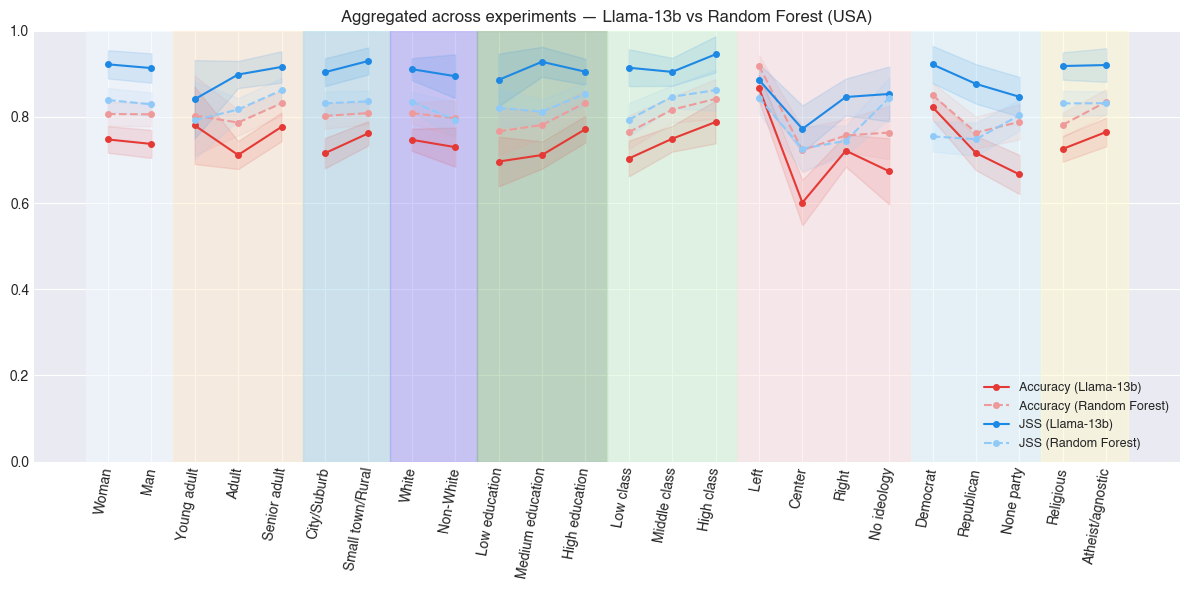

In [27]:
# Llama vs RF: Accuracy and JSS aggregated plot
fig, ax = plt.subplots(figsize=(12, 6))
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

grupos = {
    "Gender": (0, 1), "Age": (2, 4), "Zone": (5, 6),
    "Race": (7, 8), "Education": (9, 11),
    "GSE": (12, 14), "Ideology": (15, 18),
    "Party": (19, 21), "Religion": (22, 23),
}
colores_bg = {
    "Gender": "#f0f8ff", "Age": "#ffebcd", "Zone": "#add8e6",
    "Race": "#A49CF2", "Education": "#8FBC8F",
    "GSE": "#d3f8d3", "Ideology": "#ffe4e1",
    "Party": "#e0f7fa", "Religion": "#fffacd",
}
for grupo, (inicio, fin) in grupos.items():
    ax.axvspan(inicio - 0.5, fin + 0.5, color=colores_bg[grupo], alpha=0.5)

models = [
    {"data": agg_llama, "name": "Llama-13b"},
    {"data": agg_rf, "name": "Random Forest"},
]

metrics_to_plot = {
    "Accuracy": {"Llama-13b": "#e53935", "Random Forest": "#ef9a9a"},
    "JSS": {"Llama-13b": "#1e88e5", "Random Forest": "#90caf9"},
}

exclude_groups = ["No religion response", "Total"]

for metric, model_colors in metrics_to_plot.items():
    ci_lo = f"{metric}_CI_lower"
    ci_hi = f"{metric}_CI_upper"
    for model in models:
        data = model["data"].copy()
        data = data[~data['Group'].isin(exclude_groups)]
        data = data.reset_index(drop=True)

        color = model_colors[model["name"]]
        has_ci = ci_lo in data.columns and ci_hi in data.columns
        label = f"{metric} ({model['name']})"
        linestyle = '-' if model["name"] == "Llama-13b" else '--'

        for grupo, (inicio, fin) in grupos.items():
            x = list(range(inicio, fin + 1))
            y = data[metric].iloc[inicio:fin + 1].astype(float)
            ax.plot(x, y, linestyle + 'o', label=label if grupo == "Gender" else "",
                    color=color, markersize=4)
            if has_ci:
                y_lo = data[ci_lo].iloc[inicio:fin + 1].astype(float)
                y_hi = data[ci_hi].iloc[inicio:fin + 1].astype(float)
                ax.fill_between(x, y_lo, y_hi, color=color, alpha=0.12)

data_labels = agg_llama[~agg_llama['Group'].isin(exclude_groups)].reset_index(drop=True)

ax.set_ylim(0, 1)
ax.set_xticks(range(len(data_labels["Group"])))
ax.set_xticklabels(data_labels["Group"], rotation=80, ha='right')
ax.legend(loc='lower right', fontsize=9)
ax.set_title("Aggregated across experiments \u2014 Llama-13b vs Random Forest (USA)")

for label in ax.get_xticklabels():
    offset = ScaledTranslation(5/72, 0, fig.dpi_scale_trans)
    label.set_transform(label.get_transform() + offset)

plt.tight_layout()
plt.show()

In [28]:
# Compute ratio Llama / RF with Delta Method CIs
ratio_df = agg_llama[["Group"]].copy()

for metric in ["Accuracy", "JSS", "Kappa"]:
    ci_lo = f"{metric}_CI_lower"
    ci_hi = f"{metric}_CI_upper"

    x = agg_llama[metric].astype(float)           # Llama
    y = agg_rf[metric].astype(float)               # RF
    se_x = (agg_llama[ci_hi].astype(float) - agg_llama[ci_lo].astype(float)) / (2 * z)
    se_y = (agg_rf[ci_hi].astype(float) - agg_rf[ci_lo].astype(float)) / (2 * z)

    r = x / y
    se_r = r * np.sqrt((se_x / x)**2 + (se_y / y)**2)

    ratio_df[metric] = r
    ratio_df[f"{metric}_CI_lower"] = r - z * se_r
    ratio_df[f"{metric}_CI_upper"] = r + z * se_r

ratio_df

,Group,Accuracy,Accuracy_CI_lower,Accuracy_CI_upper,JSS,JSS_CI_lower,JSS_CI_upper,Kappa,Kappa_CI_lower,Kappa_CI_upper
0,Woman,0.926801,0.877263,0.976340,1.098719,1.045429,1.152009,0.886609,0.772642,1.000576
1,Man,0.914759,0.863457,0.966061,1.101575,1.046917,1.156232,0.843588,0.734808,0.952367
2,Young adult,0.971497,0.813480,1.129515,1.061174,0.894760,1.227587,0.981208,0.550947,1.411470
3,Adult,0.904307,0.850567,0.958047,1.099300,1.046963,1.151637,0.834835,0.714242,0.955428
4,Senior adult,0.934106,0.882750,0.985462,1.062820,1.007929,1.117711,0.884772,0.781336,0.988207
5,City/Suburb,0.892011,0.837069,0.946954,1.086895,1.033834,1.139955,0.789599,0.678050,0.901148
6,Small town/Rural,0.942149,0.895989,0.988309,1.112031,1.062241,1.161820,0.926148,0.807065,1.045231
7,White,0.923350,0.881431,0.965268,1.090499,1.048537,1.132462,0.869516,0.782191,0.956840
8,Non-White,0.915908,0.841246,0.990571,1.127327,1.040529,1.214126,0.875183,0.644198,1.106167
9,Low education,0.908537,0.808627,1.008446,1.079476,0.984357,1.174595,0.812879,0.611133,1.014624


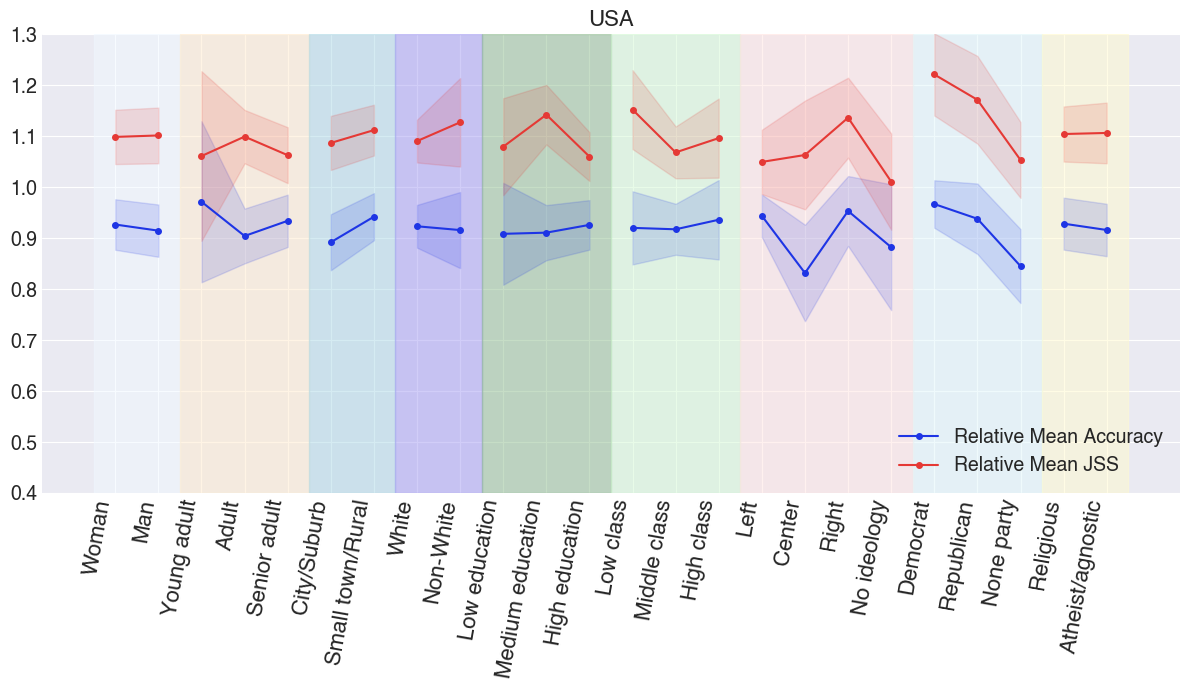

In [29]:
# Ratio plot (Llama / RF)
fig, ax = plt.subplots(figsize=(12, 7))
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

grupos = {
    "Gender": (0, 1), "Age": (2, 4), "Zone": (5, 6),
    "Race": (7, 8), "Education": (9, 11),
    "GSE": (12, 14), "Ideology": (15, 18),
    "Party": (19, 21), "Religion": (22, 23),
}
colores_bg = {
    "Gender": "#f0f8ff", "Age": "#ffebcd", "Zone": "#add8e6",
    "Race": "#A49CF2", "Education": "#8FBC8F",
    "GSE": "#d3f8d3", "Ideology": "#ffe4e1",
    "Party": "#e0f7fa", "Religion": "#fffacd",
}
for grupo, (inicio, fin) in grupos.items():
    ax.axvspan(inicio - 0.5, fin + 0.5, color=colores_bg[grupo], alpha=0.5)

# Filter rows
data = ratio_df[ratio_df['Group'] != "No religion response"]
data = data[data['Group'] != "Total"]
data = data.reset_index(drop=True)

# Plot each metric
metric_colors = {"Accuracy": "#1e35e5", "JSS": "#e53935"}
legend_names = {"Accuracy": "Relative Mean Accuracy", "JSS": "Relative Mean JSS"}
for metric, color in metric_colors.items():
    ci_lo = f"{metric}_CI_lower"
    ci_hi = f"{metric}_CI_upper"
    for grupo, (inicio, fin) in grupos.items():
        x = list(range(inicio, fin + 1))
        y = data[metric].iloc[inicio:fin + 1].astype(float)
        ax.plot(x, y, '-o', label=legend_names[metric] if grupo == "Gender" else "",
                color=color, markersize=4)
        y_lo = data[ci_lo].iloc[inicio:fin + 1].astype(float)
        y_hi = data[ci_hi].iloc[inicio:fin + 1].astype(float)
        ax.fill_between(x, y_lo, y_hi, color=color, alpha=0.15)

ax.set_ylim(bottom=0.4, top=1.3)
ax.set_xticks(range(len(data["Group"])))
ax.set_xticklabels(data["Group"], rotation=80, ha='right', fontsize=16)
ax.legend(loc='lower right', fontsize=14)
plt.yticks(fontsize=14)
ax.set_title("USA", fontsize=16)

plt.tight_layout()
fig.savefig("ratio_plot_usa.pdf", bbox_inches='tight')
plt.show()

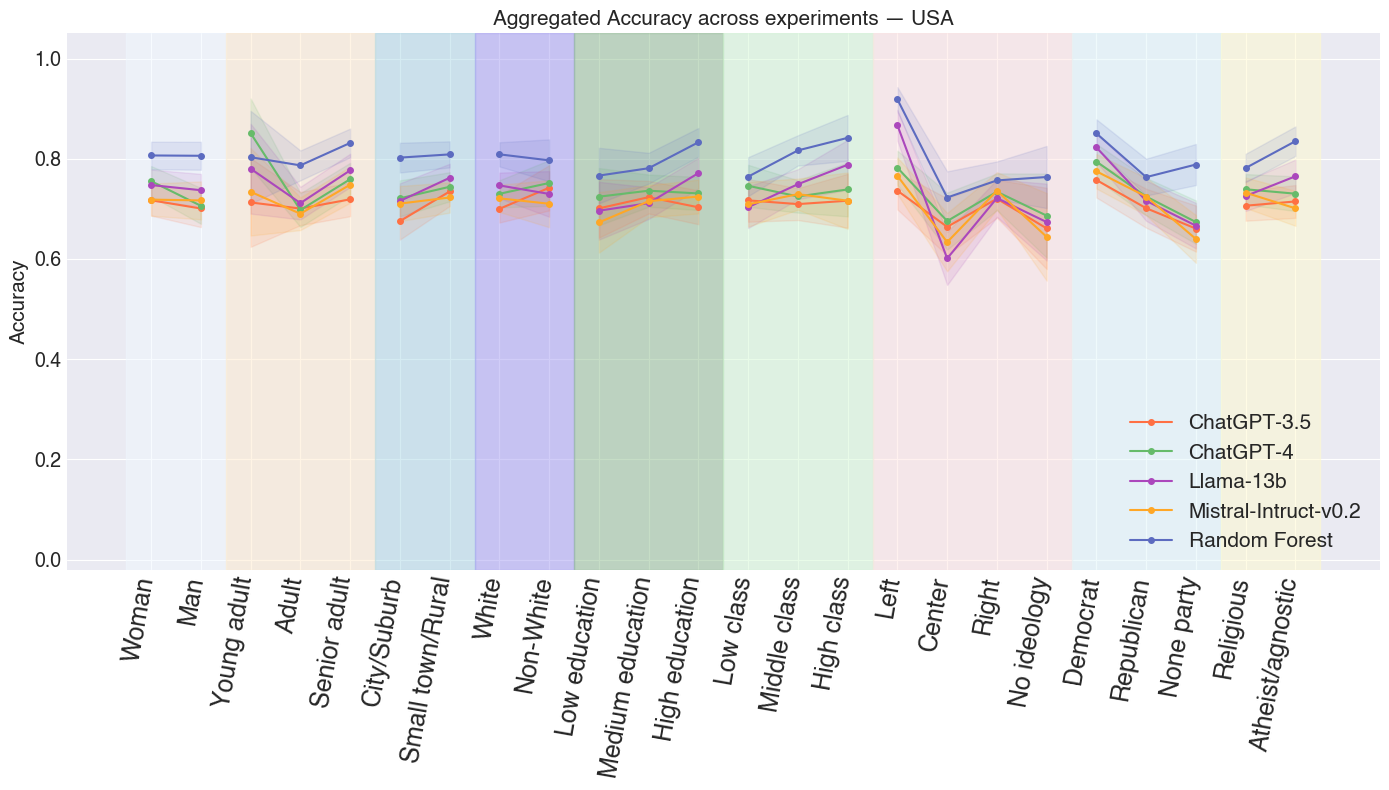

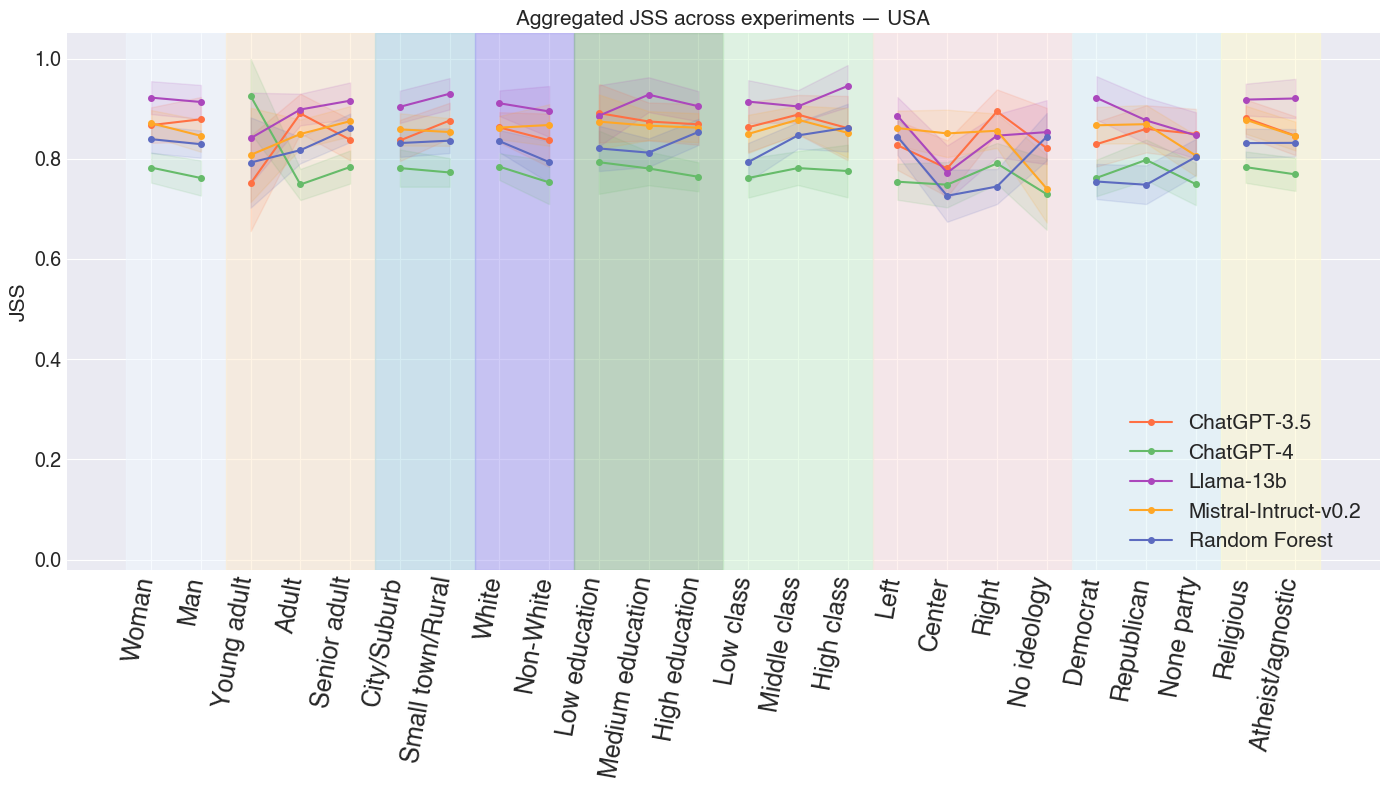

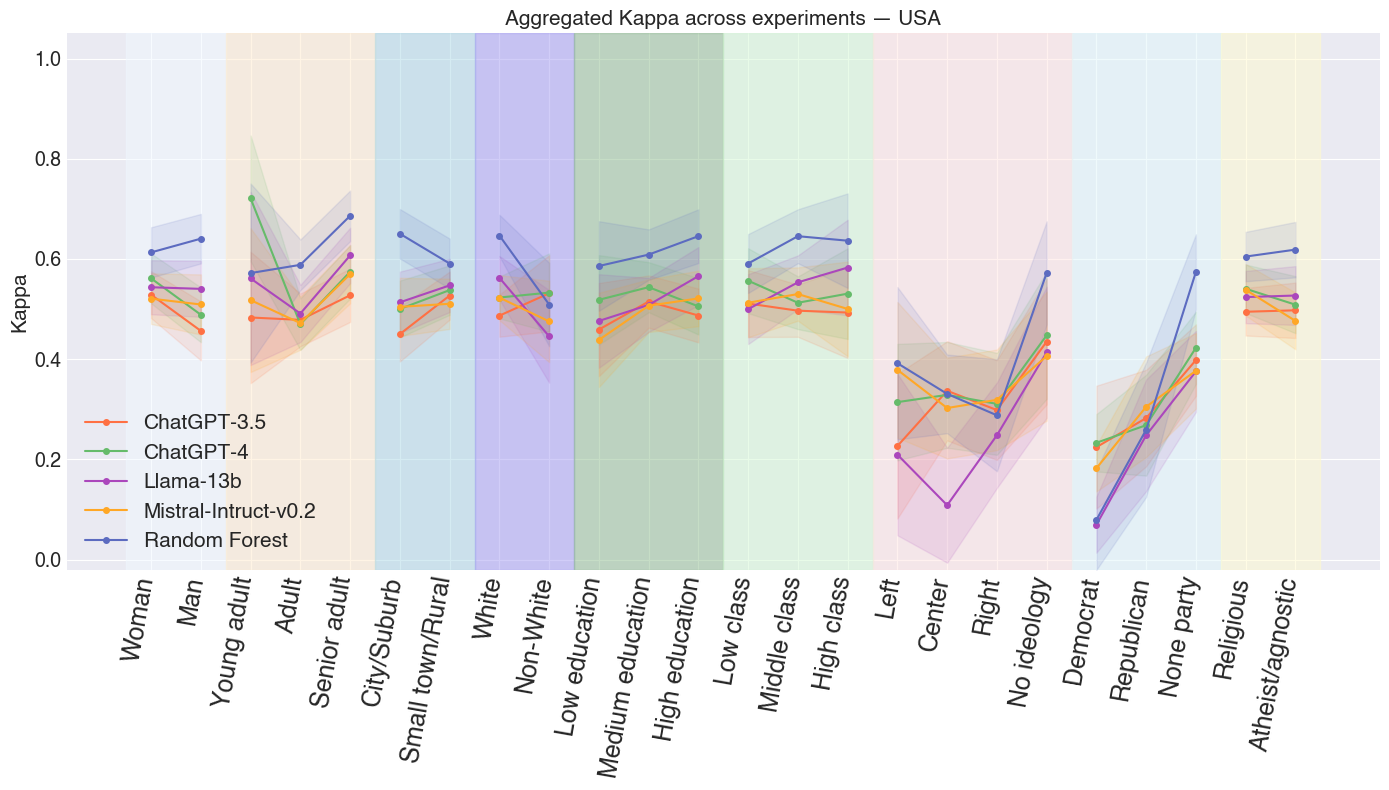

In [31]:
# All-models Accuracy/JSS/Kappa plots
all_agg_models = [
    (agg_gpt3, "ChatGPT-3.5"),
    (agg_gpt4, "ChatGPT-4"),
    (agg_llama, "Llama-13b"),
    (agg_mistral, "Mistral-Intruct-v0.2"),
    (agg_rf, "Random Forest"),
]

grupos = {
    "Gender": (0, 1), "Age": (2, 4), "Zone": (5, 6),
    "Race": (7, 8), "Education": (9, 11),
    "GSE": (12, 14), "Ideology": (15, 18),
    "Party": (19, 21), "Religion": (22, 23),
}
colores_bg = {
    "Gender": "#f0f8ff", "Age": "#ffebcd", "Zone": "#add8e6",
    "Race": "#A49CF2", "Education": "#8FBC8F",
    "GSE": "#d3f8d3", "Ideology": "#ffe4e1",
    "Party": "#e0f7fa", "Religion": "#fffacd",
}
exclude_groups = ["No religion response", "Total"]

for metric in ["Accuracy", "JSS", "Kappa"]:
    fig, ax = plt.subplots(figsize=(14, 8))
    plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

    for grupo, (inicio, fin) in grupos.items():
        ax.axvspan(inicio - 0.5, fin + 0.5, color=colores_bg[grupo], alpha=0.5)

    ci_lo_col = f"{metric}_CI_lower"
    ci_hi_col = f"{metric}_CI_upper"

    for model_data, model_name in all_agg_models:
        data = model_data.copy()
        data = data[~data['Group'].isin(exclude_groups)]
        data = data.reset_index(drop=True)
        has_ci = ci_lo_col in data.columns and ci_hi_col in data.columns
        color = modelos_colores[model_name]
        for grupo, (inicio, fin) in grupos.items():
            x = list(range(inicio, fin + 1))
            y = data[metric].iloc[inicio:fin + 1].astype(float)
            ax.plot(x, y, '-o', label=model_name if grupo == "Gender" else "",
                    color=color, markersize=4)
            if has_ci:
                y_lo = data[ci_lo_col].iloc[inicio:fin + 1].astype(float)
                y_hi = data[ci_hi_col].iloc[inicio:fin + 1].astype(float)
                ax.fill_between(x, y_lo, y_hi, color=color, alpha=0.12)

    ref_data = all_agg_models[0][0].copy()
    ref_data = ref_data[~ref_data['Group'].isin(exclude_groups)]
    ref_data = ref_data.reset_index(drop=True)

    ax.set_ylim(bottom=-0.02, top=1.05)
    ax.set_xticks(range(len(ref_data["Group"])))
    ax.set_xticklabels(ref_data["Group"], rotation=80, ha='right', fontsize=18)
    ax.legend(loc='lower right', fontsize=15)
    if metric == "Kappa":
        ax.legend(loc='lower left', fontsize=15)
    ax.set_title(f"Aggregated {metric} across experiments \u2014 USA", fontsize=15)
    ax.set_ylabel(metric, fontsize=15)
    plt.yticks(fontsize=14)

    for label in ax.get_xticklabels():
        offset = ScaledTranslation(5/72, 0, fig.dpi_scale_trans)
        label.set_transform(label.get_transform() + offset)

    plt.tight_layout()
    fig.savefig(f"mean_{metric}_usa.pdf", bbox_inches='tight')
    plt.show()